In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from ASM_utils import AdaptiveSmoothing
from matplotlib.colors import LinearSegmentedColormap
import warnings 
import os
import random
import time
warnings.filterwarnings("ignore")
device = torch.device("cpu")
lane = 1
rds = np.load(f'../data/corridor_data/rds/lane{lane}/2024-07-09.npy')
rds_filled = pd.DataFrame(rds).bfill(axis=0).ffill(axis=0).ffill(axis=1).values
speed = np.load(f'../data/corridor_data/rds/lane{lane}/2024-07-09.npy')
space_size, time_size = speed.shape
speed = torch.tensor(speed, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
best_model_path = f'../logs/calibration/20250607_203336/best_model_lane{lane}.pt'

dx = 0.02                  # distance per cell
dt = 4.0                    # time per cell
kernel_time_window = time_size * dt  # seconds
kernel_space_window = space_size * dx  # same units as dx
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Palatino']
MILE_TO_KM = 1.60934

In [2]:
# load the best model
best_model_path = f'../model/20250607_221107/best_model_lane{lane}.pt'
calibrated_model = torch.load(best_model_path, map_location=device)
calibrated = AdaptiveSmoothing(kernel_time_window,
                          kernel_space_window,
                          dx, dt,
                          init_tau=calibrated_model['tau'],
                          init_delta=calibrated_model['delta'],
                          init_c_cong=calibrated_model['c_cong'],
                          init_c_free=calibrated_model['c_free'],
                          init_v_delta=calibrated_model['v_delta'],
                          init_v_thr=calibrated_model['v_thr']
                          ).to(device)

calibrated.eval()

AdaptiveSmoothing()

In [3]:
with torch.no_grad():
    start_time = time.time()
    smoothed = calibrated(speed)
    end_time = time.time()
    print(f"Computation took {end_time - start_time:.2f} seconds")
    calibrated_asm_speed = smoothed.cpu().numpy().squeeze()

Computation took 1.09 seconds


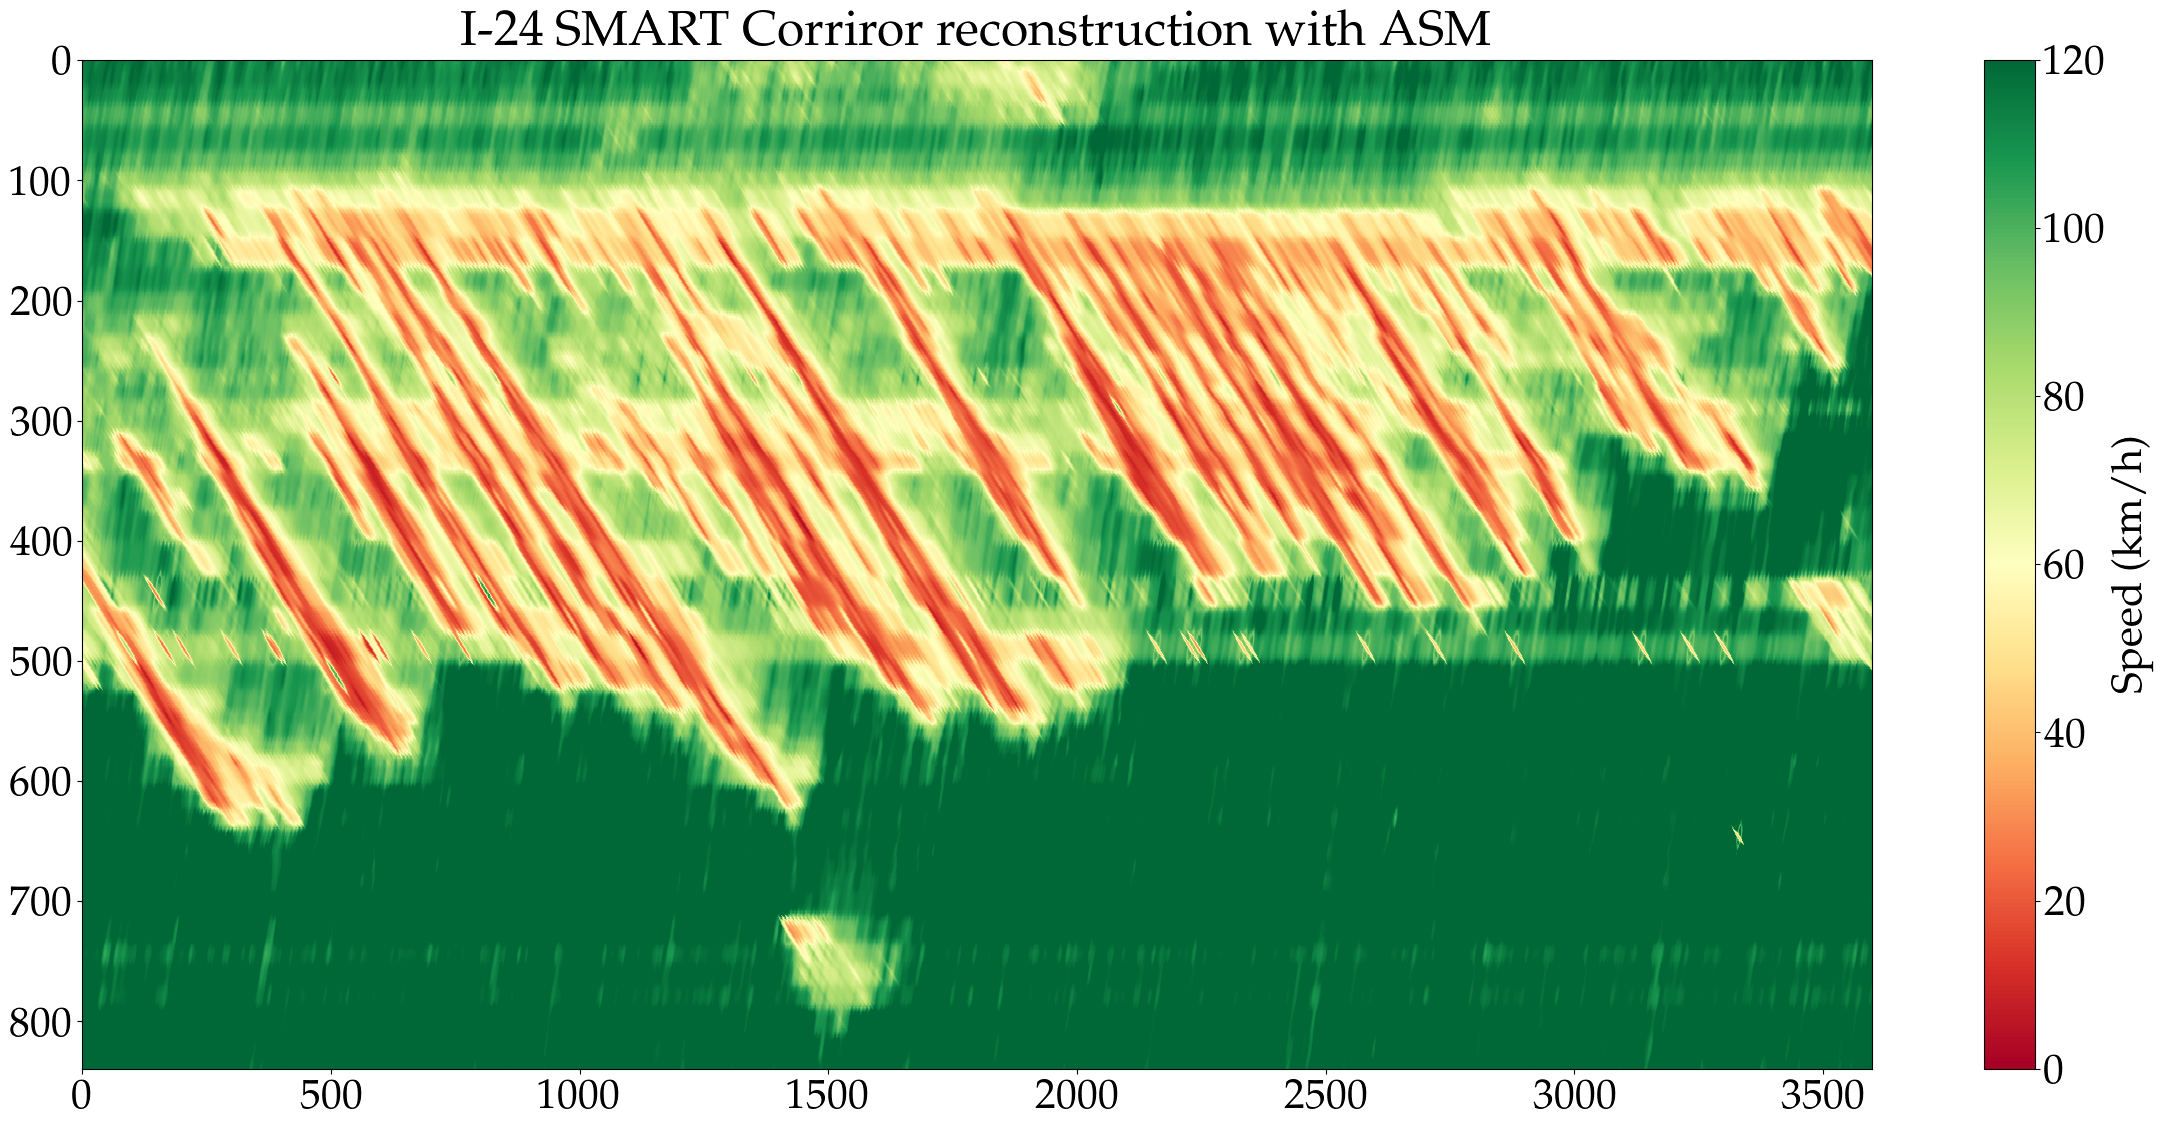

In [4]:
plt.figure(figsize=(24, 12))
plt.rcParams.update({'font.size': 30, 'font.family': 'serif'})
plt.imshow(MILE_TO_KM * calibrated_asm_speed, cmap='RdYlGn', interpolation='nearest', origin='lower',
           vmin=0, vmax=120, aspect='auto')
plt.colorbar(label='Speed (km/h)')
plt.title('I-24 SMART Corriror reconstruction with ASM')
plt.tight_layout()
# reverse y-axis to match the original plot
plt.gca().invert_yaxis()
import os
if not os.path.exists('../figures/figure9'):
    os.makedirs('../figures/figure9')
plt.savefig(f'../figures/figure9/corridor_lane{lane}.pdf', dpi=300, bbox_inches='tight')
plt.show()

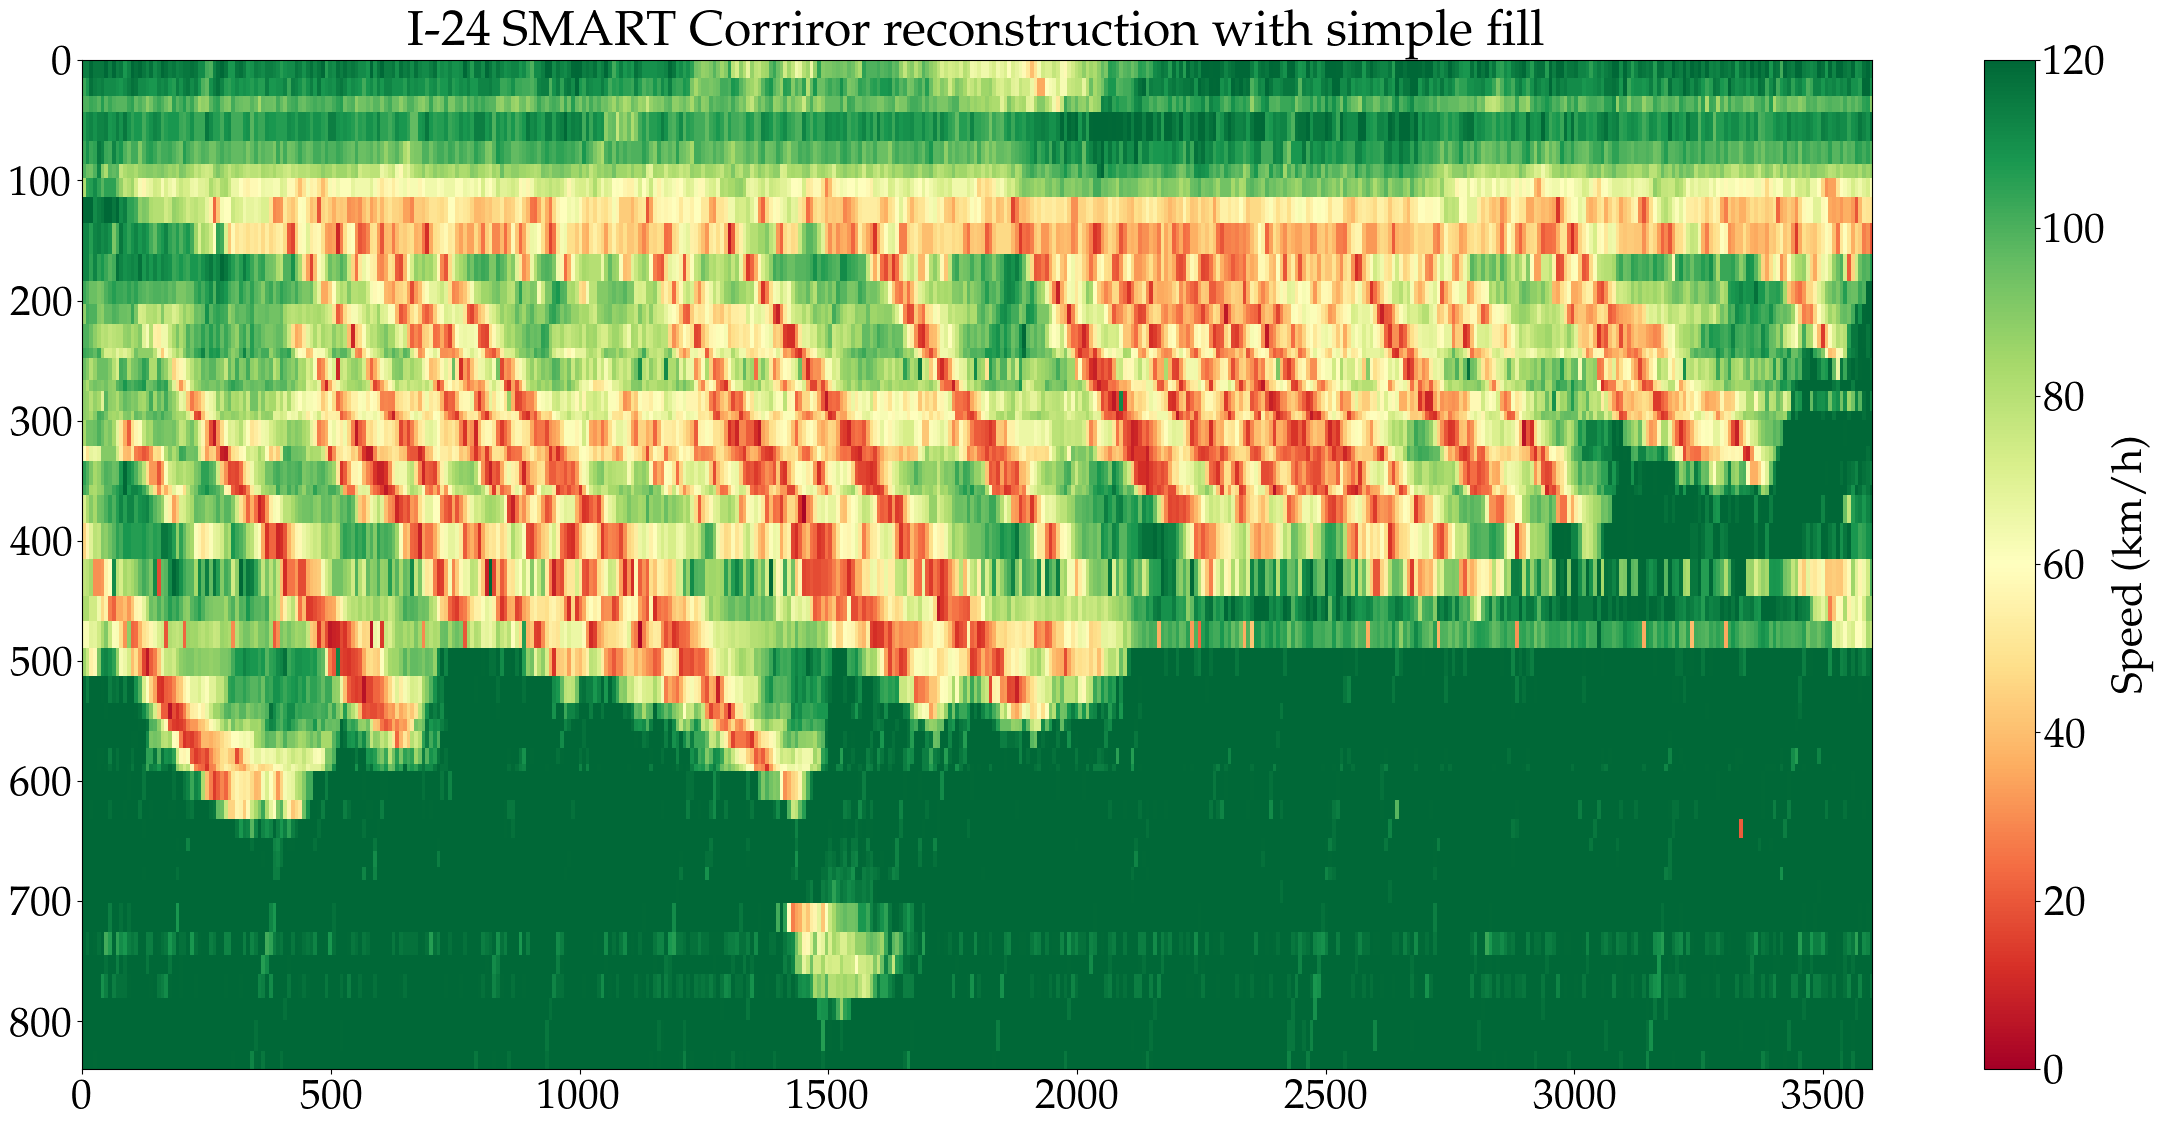

In [5]:
plt.figure(figsize=(24, 12))
plt.rcParams.update({'font.size': 30, 'font.family': 'serif'})
plt.imshow(MILE_TO_KM * rds_filled, cmap='RdYlGn', interpolation='nearest', origin='lower',
           vmin=0, vmax=120, aspect='auto')
plt.colorbar(label='Speed (km/h)')
plt.title('I-24 SMART Corriror reconstruction with simple fill')
plt.tight_layout()
# reverse y-axis to match the original plot
plt.gca().invert_yaxis()
import os
if not os.path.exists('../figures/figure9'):
    os.makedirs('../figures/figure9')
plt.savefig(f'../figures/figure9/corridor_lane{lane}_simple.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# caluclate the percentage of missing data in rds
missing_data_percentage = np.sum(np.isnan(rds)) / (rds.shape[0] * rds.shape[1]) * 100
print(f"Percentage of missing data in rds: {missing_data_percentage:.2f}%")

Percentage of missing data in rds: 99.22%
